In [1]:
from utils import *
import pandas as pd
import matplotlib.pyplot as plt

## Loading Files

In [2]:
# load all files
female_files = load_files('data/female/')
male_files   = load_files('data/male/')

female_train, female_test = split_test_ratio(female_files, 0.8)
male_train,   male_test   = split_test_ratio(male_files, 0.8)

# combine into mixed sets
train_set = female_train + male_train
test_set  = female_test  + male_test

# concatenate all training audio into one long signal
train_signal = np.concatenate([d for _, _, d in train_set])

print(f"Training: {len(female_train)} female + {len(male_train)} male files")
print(f"Testing:  {len(female_test)} female + {len(male_test)} male files")
print(f"Total training samples: {len(train_signal)} ({len(train_signal)/8000:.1f}s)")

Training: 6 female + 6 male files
Testing:  2 female + 2 male files
Total training samples: 319288 (39.9s)


## Quantisation

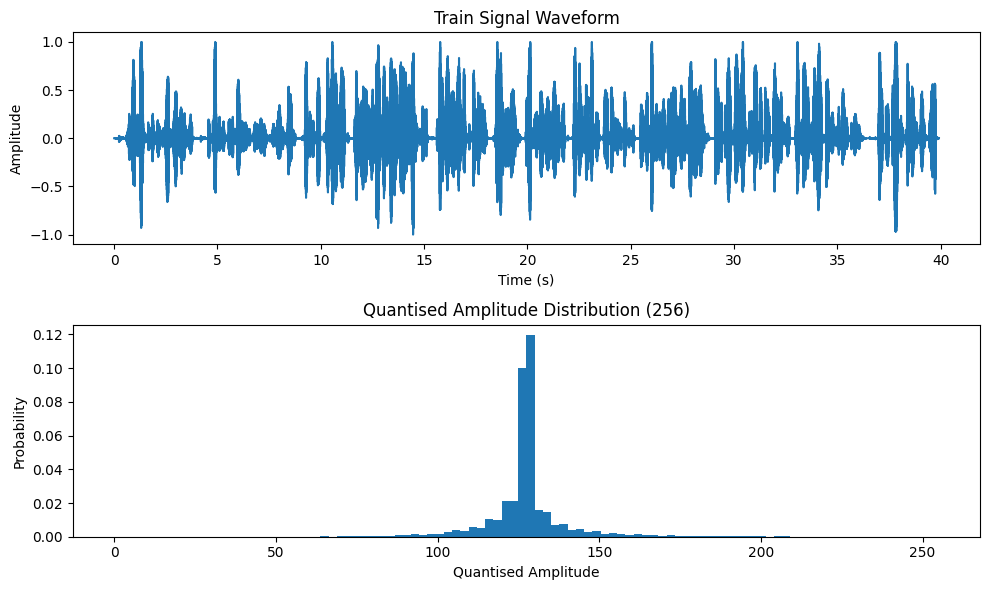

In [3]:
# feeding train signal into quantisation
quantisation = 256

idx_train, centres_train = quantize(train_signal, quantisation)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# waveform
ax1.plot(np.arange(len(train_signal)) / 8000, train_signal)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Train Signal Waveform')

# amplitude histogram
ax2.hist(idx_train, bins=100, density=True)
ax2.set_xlabel(f'Quantised Amplitude')
ax2.set_ylabel('Probability')
ax2.set_title(f'Quantised Amplitude Distribution ({quantisation})')

plt.tight_layout()
plt.show()



## Huffman Table Construction

In [4]:
huffman_codes, frequencies = build_codebook(idx_train, quantisation)

print(huffman_codes)

encoded_train_signal = encode(idx_train, huffman_codes)

reconstructed_train_signal = decode(encoded_train_signal, huffman_codes)

idx_train, centres_train = quantize(train_signal, quantisation)
reconstructed = centres_train[idx_train]
error = train_signal - reconstructed


{np.int64(128): '01', np.int64(127): '110', np.int64(129): '0010', np.int64(126): '1000', np.int64(123): '00010', np.int64(124): '10010', np.int64(130): '10100', np.int64(125): '11101', np.int64(118): '000001', np.int64(134): '000011', np.int64(119): '001101', np.int64(120): '100110', np.int64(133): '100111', np.int64(121): '101101', np.int64(132): '101110', np.int64(122): '111101', np.int64(131): '111111', np.int64(112): '0000000', np.int64(141): '0000001', np.int64(140): '0000101', np.int64(139): '0001110', np.int64(113): '0001111', np.int64(114): '0011100', np.int64(138): '0011110', np.int64(115): '1010101', np.int64(137): '1011000', np.int64(116): '1011110', np.int64(136): '1110001', np.int64(117): '1110011', np.int64(135): '1111001', np.int64(105): '00001001', np.int64(106): '00011010', np.int64(147): '00110000', np.int64(146): '00110010', np.int64(107): '00111011', np.int64(145): '00111110', np.int64(108): '10101100', np.int64(144): '10101110', np.int64(109): '10110010', np.int64

## Baseline validation and evaluation

Roundtrip OK
Compression ratio:   1.647x
Entropy:             4.8390 bits
Avg codeword length: 4.8624 bits
Efficiency:          0.9952


,file,compression_ratio,snr_db,rms_error,max_error
0,SX304.wav,1.868456,29.358854,0.002507,0.003906
1,SX34.wav,1.878872,30.362848,0.002665,0.003906
2,SX374.wav,1.827242,31.191627,0.002502,0.003906
3,SX389.wav,1.836486,29.643391,0.002419,0.003906



Average compression ratio: 1.853x
Average SNR:               30.14 dB
Average RMS error:         0.002523


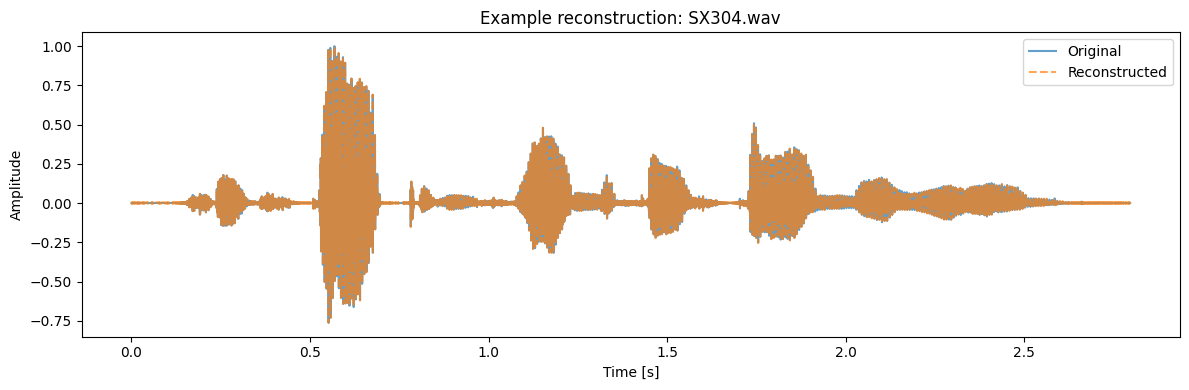

In [5]:
# ============================================================
# baseline validation and evaluation
# ============================================================


# ---- training-set sanity check ----
assert list(reconstructed_train_signal) == list(idx_train), "Roundtrip failed!"
print("Roundtrip OK")

original_bits = len(idx_train) * np.log2(quantisation)
compressed_bits = len(encoded_train_signal)
compression_ratio = original_bits / compressed_bits

total = sum(frequencies.values())
probs = np.array([v / total for v in frequencies.values()])
entropy = -np.sum(probs * np.log2(probs))
avg_length = sum(len(huffman_codes[s]) * frequencies[s] for s in frequencies) / total

print(f"Compression ratio:   {compression_ratio:.3f}x")
print(f"Entropy:             {entropy:.4f} bits")
print(f"Avg codeword length: {avg_length:.4f} bits")
print(f"Efficiency:          {entropy / avg_length:.4f}")


# ---- test-set evaluation ----
results = []
example = None

for fname, sr, signal in test_set:
    idx, centres = quantize(signal, quantisation)

    encoded = encode(idx, huffman_codes)
    decoded_idx = np.array(decode(encoded, huffman_codes))

    reconstructed = centres[decoded_idx]
    error = signal - reconstructed

    original_bits = len(idx) * np.log2(quantisation)
    compressed_bits = len(encoded)

    results.append({
        "file": fname,
        "compression_ratio": original_bits / compressed_bits,
        "snr_db": snr_db(signal, reconstructed),
        "rms_error": np.sqrt(np.mean(error**2)),
        "max_error": np.max(np.abs(error)),
    })

    if example is None:
        example = fname, sr, signal, reconstructed


results_df = pd.DataFrame(results)
display(results_df)

print(f"\nAverage compression ratio: {results_df['compression_ratio'].mean():.3f}x")
print(f"Average SNR:               {results_df['snr_db'].mean():.2f} dB")
print(f"Average RMS error:         {results_df['rms_error'].mean():.6f}")


# ---- one waveform example ----
fname, sr, signal, reconstructed = example
t = np.arange(len(signal)) / sr

plt.figure(figsize=(12, 4))
plt.plot(t, signal, label="Original", alpha=0.7)
plt.plot(t, reconstructed, label="Reconstructed", alpha=0.7, linestyle="--")
plt.title(f"Example reconstruction: {fname}")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

## Experiment 1 — Number of Quantisation Levels

   8 levels | train ratio=1.874x | test ratio=1.913x | train SNR=0.61 dB | test SNR=-2.27 dB
  16 levels | train ratio=2.113x | test ratio=2.352x | train SNR=7.18 dB | test SNR=4.31 dB
  32 levels | train ratio=2.051x | test ratio=2.416x | train SNR=13.69 dB | test SNR=10.86 dB
  64 levels | train ratio=1.889x | test ratio=2.143x | train SNR=20.17 dB | test SNR=17.32 dB
 128 levels | train ratio=1.764x | test ratio=2.007x | train SNR=26.58 dB | test SNR=23.75 dB
 256 levels | train ratio=1.647x | test ratio=1.853x | train SNR=32.92 dB | test SNR=30.14 dB
 512 levels | train ratio=1.554x | test ratio=1.717x | train SNR=39.26 dB | test SNR=36.58 dB
1024 levels | train ratio=1.486x | test ratio=1.632x | train SNR=45.52 dB | test SNR=43.04 dB
2048 levels | train ratio=1.427x | test ratio=1.564x | train SNR=51.65 dB | test SNR=49.23 dB


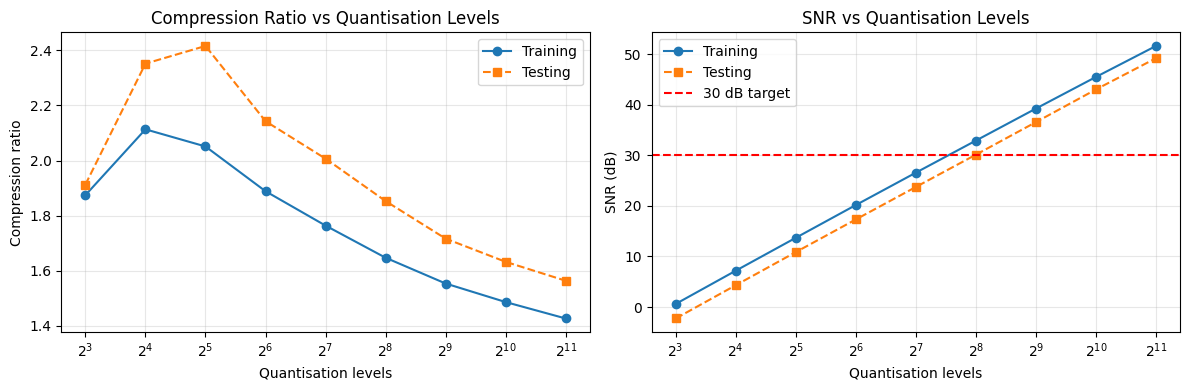

In [6]:
levels_to_test = [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
results_by_level = {}

for n_levels in levels_to_test:
    # build Huffman table from training signal for this quantisation level
    idx_train, centres_train = quantize(train_signal, n_levels)

    codes, freqs = build_codebook(idx_train, n_levels)

    # ---------- evaluate on training signal ----------
    encoded_train = encode(idx_train, codes)
    decoded_train = np.array(decode(encoded_train, codes), dtype=int)

    reconstructed_train = centres_train[decoded_train]
    error_train = train_signal - reconstructed_train

    train_ratio = len(idx_train) * np.log2(n_levels) / len(encoded_train)
    train_snr = 10 * np.log10(
        np.mean(train_signal**2) / np.mean(error_train**2)
    )

    # ---------- evaluate on test set ----------
    test_ratios, test_snrs = [], []

    for fname, sr, signal in test_set:
        idx_test, centres_test = quantize(signal, n_levels)

        encoded_test = encode(idx_test, codes)
        decoded_test = np.array(decode(encoded_test, codes), dtype=int)

        reconstructed_test = centres_test[decoded_test]
        error_test = signal - reconstructed_test

        test_ratio = len(idx_test) * np.log2(n_levels) / len(encoded_test)
        test_snr = 10 * np.log10(
            np.mean(signal**2) / np.mean(error_test**2)
        )

        test_ratios.append(test_ratio)
        test_snrs.append(test_snr)

    results_by_level[n_levels] = {
        "train_ratio": train_ratio,
        "train_snr": train_snr,
        "test_ratio": np.mean(test_ratios),
        "test_snr": np.mean(test_snrs)
    }

    print(
        f"{n_levels:4d} levels | "
        f"train ratio={train_ratio:.3f}x | "
        f"test ratio={np.mean(test_ratios):.3f}x | "
        f"train SNR={train_snr:.2f} dB | "
        f"test SNR={np.mean(test_snrs):.2f} dB"
    )


# ---------- plot train vs test tradeoff ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

train_ratios = [results_by_level[n]["train_ratio"] for n in levels_to_test]
test_ratios  = [results_by_level[n]["test_ratio"] for n in levels_to_test]

train_snrs = [results_by_level[n]["train_snr"] for n in levels_to_test]
test_snrs  = [results_by_level[n]["test_snr"] for n in levels_to_test]


# Compression ratio plot
ax1.plot(levels_to_test, train_ratios, "o-", label="Training")
ax1.plot(levels_to_test, test_ratios, "s--", label="Testing")

ax1.set_xlabel("Quantisation levels")
ax1.set_ylabel("Compression ratio")
ax1.set_title("Compression Ratio vs Quantisation Levels")
ax1.set_xscale("log", base=2)
ax1.legend()
ax1.grid(True, alpha=0.3)


# SNR plot
ax2.plot(levels_to_test, train_snrs, "o-", label="Training")
ax2.plot(levels_to_test, test_snrs, "s--", label="Testing")

ax2.set_xlabel("Quantisation levels")
ax2.set_ylabel("SNR (dB)")
ax2.set_title("SNR vs Quantisation Levels")
ax2.set_xscale("log", base=2)
ax2.axhline(y=30, color="r", linestyle="--", label="30 dB target")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Experiment 2 — Training Data Size

In [7]:
# ============================================================
# Experiment 2: Effect of training data size
# Mixed shuffled training pool version
# With training and testing curves
# ============================================================

n_levels = 256

# Fixed mixed-gender test set
test_set = female_test + male_test

# Training durations to test, in seconds
training_durations = [0.25, 0.5, 1, 2, 4, 8, 12, 16, 24, 32]


# Build one shuffled mixed-gender training pool
train_pool, sr_train = make_mixed_training_pool(
    female_train,
    male_train,
    seed=0
)

max_duration = len(train_pool) / sr_train
print(f"Total available training duration: {max_duration:.2f} s")


results_by_duration = {}

for duration in training_durations:
    # --------------------------------------------------------
    # Select increasing portion of the shuffled training pool
    # --------------------------------------------------------
    n_samples = int(duration * sr_train)
    n_samples = min(n_samples, len(train_pool))

    train_subset = train_pool[:n_samples]

    # --------------------------------------------------------
    # Build Huffman table from this training subset
    # --------------------------------------------------------
    idx_train, centres_train = quantize(train_subset, n_levels)

    codes, freqs = build_codebook(idx_train, n_levels)

    # --------------------------------------------------------
    # Training statistics: entropy, average code length, efficiency
    # --------------------------------------------------------
    total = sum(freqs.values())

    entropy = -sum(
        (freq / total) * np.log2(freq / total)
        for freq in freqs.values()
    )

    avg_code_length = sum(
        (freq / total) * len(codes[symbol])
        for symbol, freq in freqs.items()
    )

    efficiency = entropy / avg_code_length

    # --------------------------------------------------------
    # Evaluate on the training subset itself
    # --------------------------------------------------------
    encoded_train = encode(idx_train, codes)
    decoded_train = np.array(decode(encoded_train, codes), dtype=int)

    reconstructed_train = centres_train[decoded_train]
    error_train = train_subset - reconstructed_train

    train_ratio = len(idx_train) * np.log2(n_levels) / len(encoded_train)

    train_snr = 10 * np.log10(
        np.mean(train_subset**2) / np.mean(error_train**2)
    )

    # --------------------------------------------------------
    # Evaluate on fixed mixed-gender test set
    # --------------------------------------------------------
    test_ratios = []
    test_snrs = []

    for fname, sr, signal in test_set:
        idx_test, centres_test = quantize(signal, n_levels)

        encoded_test = encode(idx_test, codes)
        decoded_test = np.array(decode(encoded_test, codes), dtype=int)

        reconstructed_test = centres_test[decoded_test]
        error_test = signal - reconstructed_test

        test_ratio = len(idx_test) * np.log2(n_levels) / len(encoded_test)

        test_snr = 10 * np.log10(
            np.mean(signal**2) / np.mean(error_test**2)
        )

        test_ratios.append(test_ratio)
        test_snrs.append(test_snr)

    results_by_duration[duration] = {
        "n_train_samples": n_samples,
        "entropy": entropy,
        "avg_code_length": avg_code_length,
        "efficiency": efficiency,
        "train_ratio": train_ratio,
        "train_snr": train_snr,
        "test_ratio": np.mean(test_ratios),
        "test_snr": np.mean(test_snrs)
    }

    print(
        f"{duration:>5.2f}s | "
        f"samples={n_samples:>6} | "
        f"train ratio={train_ratio:.3f}x | "
        f"test ratio={np.mean(test_ratios):.3f}x | "
        f"train SNR={train_snr:.2f} dB | "
        f"test SNR={np.mean(test_snrs):.2f} dB | "
        f"entropy={entropy:.3f} | "
        f"avg length={avg_code_length:.3f} | "
        f"eff={100*efficiency:.2f}%"
    )

Total available training duration: 39.91 s
 0.25s | samples=  2000 | train ratio=1.629x | test ratio=1.803x | train SNR=32.92 dB | test SNR=30.14 dB | entropy=5.442 | avg length=5.479 | eff=99.33%
 0.50s | samples=  4000 | train ratio=1.654x | test ratio=1.828x | train SNR=32.65 dB | test SNR=30.14 dB | entropy=5.151 | avg length=5.177 | eff=99.51%
 1.00s | samples=  8000 | train ratio=1.651x | test ratio=1.845x | train SNR=33.05 dB | test SNR=30.14 dB | entropy=5.011 | avg length=5.035 | eff=99.53%
 2.00s | samples= 16000 | train ratio=1.655x | test ratio=1.849x | train SNR=32.83 dB | test SNR=30.14 dB | entropy=4.911 | avg length=4.935 | eff=99.53%
 4.00s | samples= 32000 | train ratio=1.649x | test ratio=1.850x | train SNR=32.91 dB | test SNR=30.14 dB | entropy=4.881 | avg length=4.904 | eff=99.53%
 8.00s | samples= 64000 | train ratio=1.647x | test ratio=1.852x | train SNR=32.98 dB | test SNR=30.14 dB | entropy=4.862 | avg length=4.886 | eff=99.51%
12.00s | samples= 96000 | train r

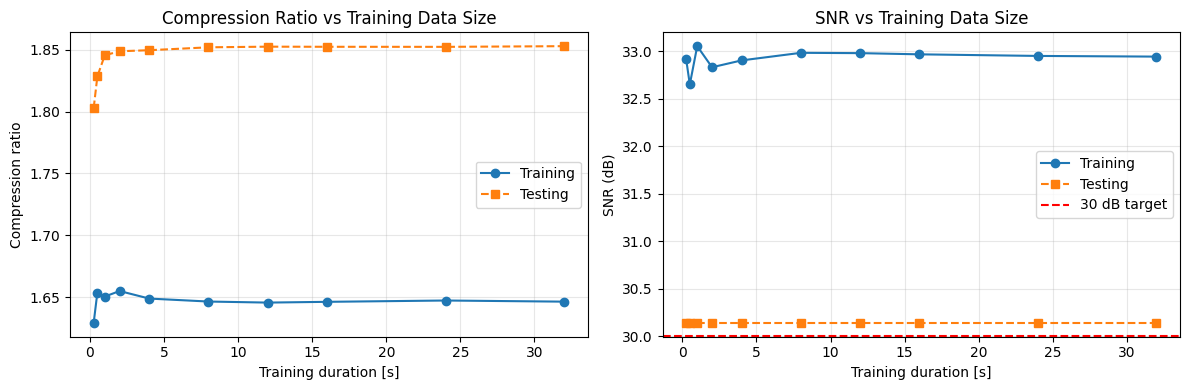

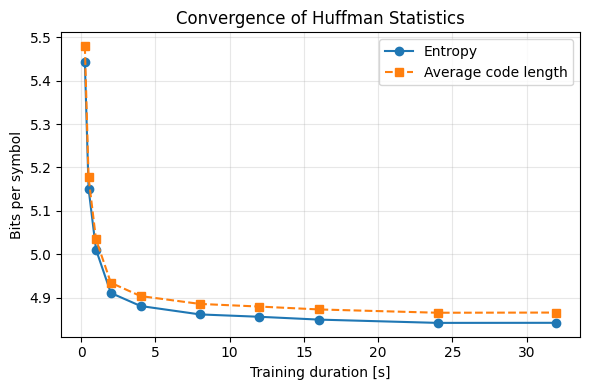

In [8]:
# ============================================================
# Plot train vs test results for training data size experiment
# ============================================================

durations = training_durations

train_ratios = [results_by_duration[d]["train_ratio"] for d in durations]
test_ratios  = [results_by_duration[d]["test_ratio"] for d in durations]

train_snrs = [results_by_duration[d]["train_snr"] for d in durations]
test_snrs  = [results_by_duration[d]["test_snr"] for d in durations]

entropies = [results_by_duration[d]["entropy"] for d in durations]
avg_lengths = [results_by_duration[d]["avg_code_length"] for d in durations]


# ---------- plot train vs test compression and SNR ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Compression ratio plot
ax1.plot(durations, train_ratios, "o-", label="Training")
ax1.plot(durations, test_ratios, "s--", label="Testing")

ax1.set_xlabel("Training duration [s]")
ax1.set_ylabel("Compression ratio")
ax1.set_title("Compression Ratio vs Training Data Size")
ax1.legend()
ax1.grid(True, alpha=0.3)


# SNR plot
ax2.plot(durations, train_snrs, "o-", label="Training")
ax2.plot(durations, test_snrs, "s--", label="Testing")

ax2.set_xlabel("Training duration [s]")
ax2.set_ylabel("SNR (dB)")
ax2.set_title("SNR vs Training Data Size")
ax2.axhline(y=30, color="r", linestyle="--", label="30 dB target")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ---------- plot entropy and average code length ----------
plt.figure(figsize=(6, 4))

plt.plot(durations, entropies, "o-", label="Entropy")
plt.plot(durations, avg_lengths, "s--", label="Average code length")

plt.xlabel("Training duration [s]")
plt.ylabel("Bits per symbol")
plt.title("Convergence of Huffman Statistics")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Quantisation levels: 256
Number of Huffman code entries: 256
Training symbols: 319288
Test symbols: 84994


,method,block_size,bit_loss_probability,snr_db
0,No resynchronisation,NaN,0.00000,30.128482
1,No resynchronisation,NaN,0.00001,-0.635584
2,No resynchronisation,NaN,0.00003,-2.124462
3,No resynchronisation,NaN,0.00010,-3.128369
4,No resynchronisation,NaN,0.00030,-3.406095
5,No resynchronisation,NaN,0.00100,-4.178031
6,Block resynchronisation,128.0,0.00000,30.128482
7,Block resynchronisation,128.0,0.00001,18.101768
8,Block resynchronisation,128.0,0.00003,12.840347
9,Block resynchronisation,128.0,0.00010,7.809388


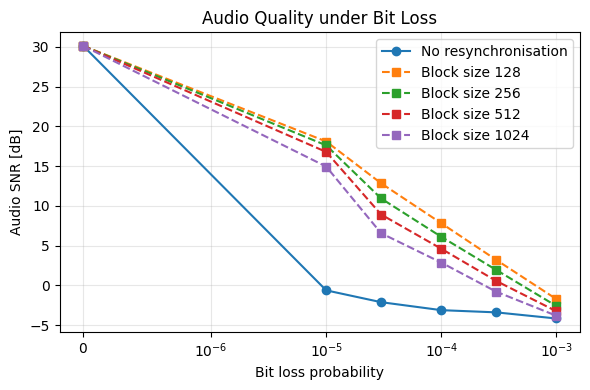

In [9]:
# ============================================================
# Experiment 3: Robustness under bit loss
# No resynchronisation vs block resynchronisation
# ============================================================

n_levels_robustness = 256
bit_loss_probs = [0, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
block_sizes = [128, 256, 512, 1024]
n_trials = 5

# Build robustness train/test data
robustness_train_set = female_train + male_train
robustness_test_set = female_test + male_test

train_signal_robustness = np.concatenate([d for _, _, d in robustness_train_set])
test_signal_robustness = np.concatenate([d for _, _, d in robustness_test_set])

train_symbols, centres = quantize(train_signal_robustness, n_levels_robustness)
test_symbols, _ = quantize(test_signal_robustness, n_levels_robustness)

codebook, frequencies = build_codebook(train_symbols, n_levels_robustness)

print("Quantisation levels:", n_levels_robustness)
print("Number of Huffman code entries:", len(codebook))
print("Training symbols:", len(train_symbols))
print("Test symbols:", len(test_symbols))


# ------------------------------------------------------------
# Shared evaluation function
# ------------------------------------------------------------

def evaluate_bit_loss_snr(symbols, original_audio, centres, codebook,
                          p_loss, block_size=None, n_trials=5):
    trial_snrs = []

    for trial in range(n_trials):
        rng = np.random.default_rng(trial)

        recovered = np.full(len(symbols), 0, dtype=int)

        if block_size is None:
            encoded = encode(symbols, codebook)
            damaged = lose_bits(encoded, p_loss, rng)
            decoded = decode_prefix(damaged, codebook, max_symbols=len(symbols))

            n = min(len(decoded), len(symbols))
            recovered[:n] = decoded[:n]

        else:
            start = 0

            for block in [
                symbols[i:i + block_size]
                for i in range(0, len(symbols), block_size)
            ]:
                encoded = encode(block, codebook)
                damaged = lose_bits(encoded, p_loss, rng)
                decoded = decode_prefix(damaged, codebook, max_symbols=len(block))

                n = min(len(decoded), len(block))
                recovered[start:start + n] = decoded[:n]

                start += len(block)

        reconstructed_audio = reconstruct_from_symbols(recovered, centres)
        trial_snrs.append(snr_db(original_audio, reconstructed_audio))

    return np.mean(trial_snrs)


# ------------------------------------------------------------
# Run experiment
# ------------------------------------------------------------

rows = []

for p_loss in bit_loss_probs:
    rows.append({
        "method": "No resynchronisation",
        "block_size": np.nan,
        "bit_loss_probability": p_loss,
        "snr_db": evaluate_bit_loss_snr(
            test_symbols,
            test_signal_robustness,
            centres,
            codebook,
            p_loss,
            block_size=None,
            n_trials=n_trials
        )
    })

for block_size in block_sizes:
    for p_loss in bit_loss_probs:
        rows.append({
            "method": "Block resynchronisation",
            "block_size": block_size,
            "bit_loss_probability": p_loss,
            "snr_db": evaluate_bit_loss_snr(
                test_symbols,
                test_signal_robustness,
                centres,
                codebook,
                p_loss,
                block_size=block_size,
                n_trials=n_trials
            )
        })


df_snr_robustness = pd.DataFrame(rows)
display(df_snr_robustness)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))

baseline = df_snr_robustness[
    df_snr_robustness["method"] == "No resynchronisation"
]

plt.plot(
    baseline["bit_loss_probability"],
    baseline["snr_db"],
    "o-",
    label="No resynchronisation"
)

for block_size in block_sizes:
    subset = df_snr_robustness[
        (df_snr_robustness["method"] == "Block resynchronisation")
        &
        (df_snr_robustness["block_size"] == block_size)
    ]

    plt.plot(
        subset["bit_loss_probability"],
        subset["snr_db"],
        "s--",
        label=f"Block size {block_size}"
    )

plt.xscale("symlog", linthresh=1e-6)
plt.xlabel("Bit loss probability")
plt.ylabel("Audio SNR [dB]")
plt.title("Audio Quality under Bit Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Experiment 4: RVLC-style recovery

Huffman average length: 4.86242583181033
RVLC average length:    5.450672421028895
Forward decode correct:  True
Backward decode correct: True


,damage_fraction,huffman_recovered_fraction,rvlc_recovered_fraction
0,0.00,1.000000,1.000000
1,0.01,0.492317,0.990081
2,0.02,0.487634,0.980622
3,0.05,0.473845,0.952548
4,0.10,0.450548,0.905615
5,0.20,0.404379,0.810288


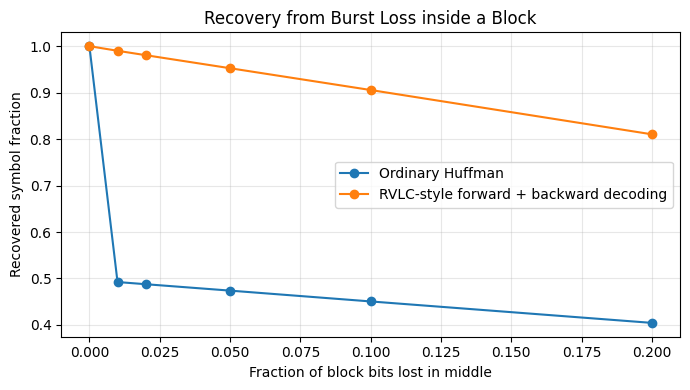

,bit_loss_probability,method,symbol_error_rate
0,0.00,Huffman: no resynchronisation,0.000000
1,0.00,Huffman block size 128,0.000000
2,0.00,RVLC block size 128,0.000000
3,0.00,Huffman block size 256,0.000000
4,0.00,RVLC block size 256,0.000000
...,...,...,...
67,0.01,RVLC block size 256,0.821797
68,0.01,Huffman block size 512,0.737285
69,0.01,RVLC block size 512,0.881875
70,0.01,Huffman block size 1024,0.763643


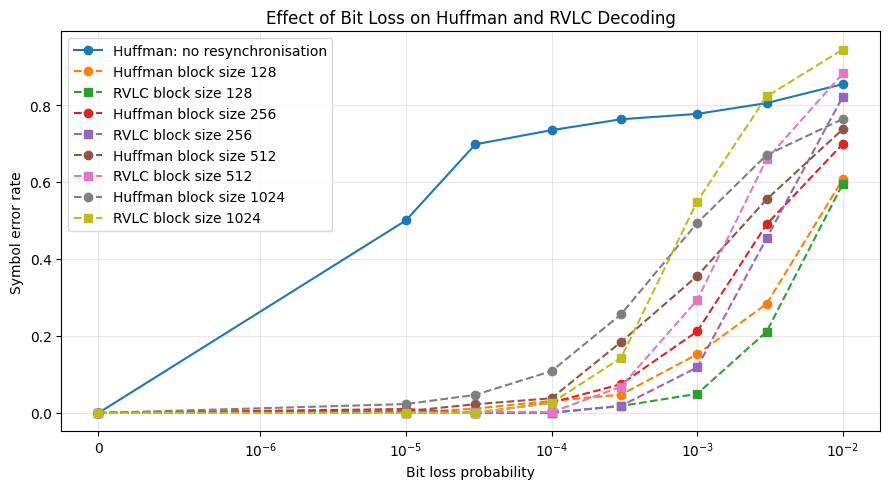

In [10]:
# ============================================================
# Experiment 4: RVLC-style recovery
# ============================================================

n_levels_rvlc = 256
block_size = 1024
damage_fractions = [0.00, 0.01, 0.02, 0.05, 0.10, 0.20]
bit_loss_probs = [0, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
block_sizes = [128, 256, 512, 1024]
n_blocks = 100

# Build symbols and codebooks
rvlc_train_set = female_train + male_train
rvlc_test_set = female_test + male_test

train_signal_rvlc = np.concatenate([d for _, _, d in rvlc_train_set])
test_signal_rvlc = np.concatenate([d for _, _, d in rvlc_test_set])

train_symbols_rvlc, _ = quantize(train_signal_rvlc, n_levels_rvlc)
test_symbols_rvlc, _ = quantize(test_signal_rvlc, n_levels_rvlc)

huffman_codebook, huffman_freqs = build_codebook(train_symbols_rvlc, n_levels_rvlc)
rvlc_codebook, rvlc_freqs = build_rvlc_codebook(train_symbols_rvlc, n_levels_rvlc)

print("Huffman average length:", average_code_length(huffman_codebook, huffman_freqs))
print("RVLC average length:   ", average_code_length(rvlc_codebook, rvlc_freqs))


# ------------------------------------------------------------
# Reversibility check
# ------------------------------------------------------------

test_short = test_symbols_rvlc[:5000]
rvlc_bits = encode_symbols(test_short, rvlc_codebook)

decoded_fwd = decode_forward(rvlc_bits, rvlc_codebook)
decoded_bwd = decode_backward(rvlc_bits, rvlc_codebook)

print("Forward decode correct: ", np.array_equal(test_short, decoded_fwd))
print("Backward decode correct:", np.array_equal(test_short, decoded_bwd))


# ------------------------------------------------------------
# Burst loss experiment
# ------------------------------------------------------------

burst_rows = []
symbols = np.array(test_symbols_rvlc, dtype=int)

for damage_fraction in damage_fractions:
    huff_rates = []
    rvlc_rates = []

    for b in range(n_blocks):
        start = b * block_size
        block = symbols[start:start + block_size]

        if len(block) < block_size:
            continue

        huff_rec = huffman_recover_from_damaged_block(
            block,
            huffman_codebook,
            damage_fraction
        )

        rvlc_rec = rvlc_recover_from_damaged_block(
            block,
            rvlc_codebook,
            damage_fraction
        )

        huff_rates.append(recovered_prefix_fraction(block, huff_rec))
        rvlc_rates.append(len(rvlc_rec) / len(block))

    burst_rows.append({
        "damage_fraction": damage_fraction,
        "huffman_recovered_fraction": np.mean(huff_rates),
        "rvlc_recovered_fraction": np.mean(rvlc_rates),
    })

rvlc_burst_results = pd.DataFrame(burst_rows)
display(rvlc_burst_results)

plt.figure(figsize=(7, 4))
plt.plot(
    rvlc_burst_results["damage_fraction"],
    rvlc_burst_results["huffman_recovered_fraction"],
    marker="o",
    label="Ordinary Huffman"
)
plt.plot(
    rvlc_burst_results["damage_fraction"],
    rvlc_burst_results["rvlc_recovered_fraction"],
    marker="o",
    label="RVLC-style forward + backward decoding"
)
plt.xlabel("Fraction of block bits lost in middle")
plt.ylabel("Recovered symbol fraction")
plt.title("Recovery from Burst Loss inside a Block")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Random bit loss experiment
# ------------------------------------------------------------

rvlc_loss_results = evaluate_rvlc_bit_loss(
    symbols=test_symbols_rvlc,
    huffman_codebook=huffman_codebook,
    rvlc_codebook=rvlc_codebook,
    bit_loss_probs=bit_loss_probs,
    block_sizes=block_sizes,
    n_blocks=n_blocks,
    seed=1
)

display(rvlc_loss_results)


plt.figure(figsize=(9, 5))

baseline = rvlc_loss_results[
    rvlc_loss_results["method"] == "Huffman: no resynchronisation"
]

plt.plot(
    baseline["bit_loss_probability"],
    baseline["symbol_error_rate"],
    marker="o",
    label="Huffman: no resynchronisation"
)

for block_size in block_sizes:
    for prefix, marker in [("Huffman", "o"), ("RVLC", "s")]:
        subset = rvlc_loss_results[
            rvlc_loss_results["method"] == f"{prefix} block size {block_size}"
        ]

        plt.plot(
            subset["bit_loss_probability"],
            subset["symbol_error_rate"],
            marker=marker,
            linestyle="--",
            label=f"{prefix} block size {block_size}"
        )

plt.xscale("symlog", linthresh=1e-6)
plt.xlabel("Bit loss probability")
plt.ylabel("Symbol error rate")
plt.title("Effect of Bit Loss on Huffman and RVLC Decoding")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()